# 1. Import Library

In [1]:
import torch
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch.optim as optim

## Read Dataset

In [2]:
# Fetch the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
assert mnist is not None, "Data and target are not found"

# Only use 20% of data
num_of_samples = mnist.data.shape[0] // 5

X_original = mnist.data[:num_of_samples]
y_original = mnist.target[:num_of_samples]

# Rescale to [0, 1.0]
X_original = X_original / 255
X_original = X_original.reshape(-1, 28, 28)


X_original.shape, y_original.shape

((14000, 28, 28), (14000,))

## Visualize data

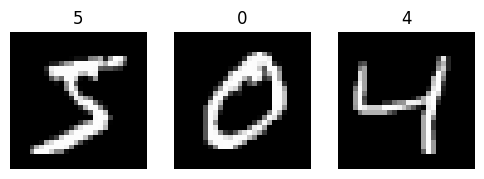

In [3]:
plt.figure(figsize=(6, 2))

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(X_original[i], cmap='gray')
    plt.title(y_original[i])
    plt.axis(False)

plt.show()

## Prepare train loader

In [4]:
from src import get_data_loader

loader = get_data_loader(train_data=X_original, batch_size=64)
# X_loader = get_data_loader(train_data=X_test, batch_size=32)

len(loader)

219

# 2. Training model

In [5]:
%reload_ext autoreload
from src import CNNAutoencoder, ModelState, PersistenceLoss
from torch.nn import MSELoss

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

torch.manual_seed(42)
# learning_rate = 0.02
learning_rate = 1e-3

model = CNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

mse_loss = MSELoss()
persistence_loss = PersistenceLoss()

model_state = ModelState(
    model, 
    # model_name="TopoAE_v0_3-7_full", 
    # loss_description=["MSELoss", "TopoLoss"], 
    # learning_rate=learning_rate, 
    # seed=30, 
    # optimizer="Adam"
)

# model_state.load_model("TopoAE_v0_3-7_full")
model_state.model.to(device)
model_state.log()

--------------------------------------------------
model: CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
model_name: Default
args: {}
loss_history: []
loss_description: ['MSELoss']
--------------------------------------------------


In [6]:
from tqdm import tqdm

num_epochs = 10

PH_LOSS_SCALE = 10

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    model.train()
    mse_acc_loss =  0
    p_acc_loss = 0
    for batch in loader:        
        batch = batch.unsqueeze(1)
        input = batch.to(device)
        x_en = model.encode(input)
        output = model.decode(x_en)

        optimizer.zero_grad()

        # Computing MSE loss
        loss = mse_loss(output, input)
        loss.backward(retain_graph=True)
        mse_acc_loss += loss

        # Computing persistence loss
        p_loss = persistence_loss(input, x_en) * PH_LOSS_SCALE
        p_loss.backward()
        p_acc_loss += p_loss
        
        # print(f"MSE Loss: {loss} - Persistence Loss: {p_loss}")
        
        optimizer.step()

    loss = mse_acc_loss.detach().cpu().numpy() / len(loader)
    p_loss = p_acc_loss.detach().cpu().numpy() / len(loader)

    print(f"MSE Loss: {loss} - Persistence Loss: {p_loss}")

    model_state.loss_record([loss, p_loss])

# print("Training complete ! Saving model...")
# torch.save(model.state_dict(), "topo_ae.pt")

Epochs:  10%|█         | 1/10 [00:54<08:06, 54.08s/it]

MSE Loss: 0.09432554898196704 - Persistence Loss: 0.00999070846871154


Epochs:  20%|██        | 2/10 [01:50<07:22, 55.26s/it]

MSE Loss: 0.043835378672978646 - Persistence Loss: 0.0037371630537999818


Epochs:  30%|███       | 3/10 [02:43<06:21, 54.47s/it]

...

MSE Loss: 0.013114044111068935 - Persistence Loss: 0.0019896993898365595


Epochs:  90%|█████████ | 9/10 [08:04<00:52, 52.86s/it]

MSE Loss: 0.012316531786635587 - Persistence Loss: 0.0018241713036140895


Epochs: 100%|██████████| 10/10 [08:56<00:00, 53.65s/it]

MSE Loss: 0.01162254211565131 - Persistence Loss: 0.0018166304995480193


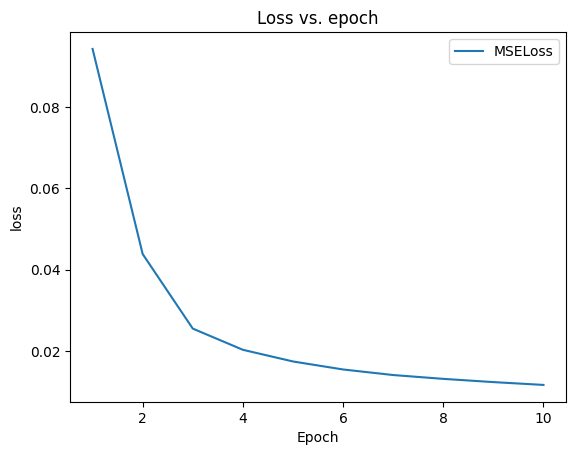

In [7]:
model_state.visualize_loss()

# 3. Test model

## 3.1 Load pretrained model

In [ ]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"Use device: {device}")

# model_state.load_model("TopoAE_v0_3-7_full")
# model_state.model.to(device)
# model_state.log()

Use device: cpu
Model loaded from /Users/tranquochieu/Documents/NCKH/Homology persistent/code/topology_autoencoder/models/TopoAE_v0_3-7_full
--------------------------------------------------
model: CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
model_name: TopoAE_v0_3-7_full
args: {'seed': 42, 'optimizer': 'Adam', 'lr': 0.001, 'batch_size': 32, 'ploss_scale': 10}
loss_history: [[0.03433, 0.00556

## 3.2 Compressed the data

In [8]:
from src.data_processing import get_data_loader

loader = get_data_loader(train_data=X_original, batch_size=32, shuffle=False)
# model = model_state.model

X_compressed_list = []

model.eval()
for batch in loader:
    with torch.no_grad():
        batch = batch.to(device)
        batch = batch.unsqueeze(1)
        X_encoded = model.encode(batch)
        X_compressed_list.append(X_encoded.detach().cpu().numpy())

X_compressed = np.concatenate(X_compressed_list, axis=0)
X_compressed = X_compressed.squeeze()
X_compressed.shape, y_original.shape

((14000, 64), (14000,))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_compressed_scaled = scaler.fit_transform(X_compressed)
X_compressed_scaled.shape

(14000, 64)

## 3.3 Split data into training vs. testing set

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_compressed_scaled, y_original, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11200, 64), (2800, 64), (11200,), (2800,))

## 3.4 Train and test on Logistic Regression model

Training: 100%|██████████| 30/30 [00:08<00:00,  3.41it/s]


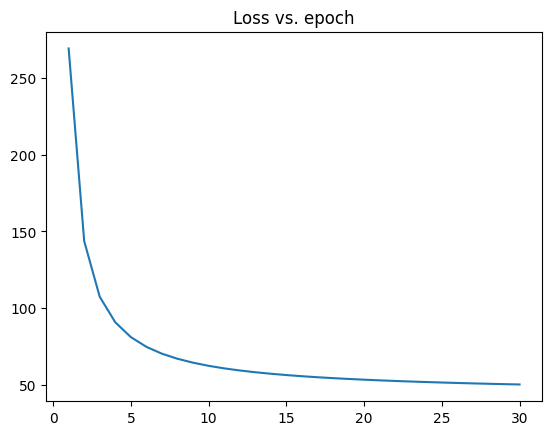

In [13]:
%reload_ext autoreload
# %autoreload 2

from src.models import LogisticRegModel

num_epochs = 30
logistic_model = LogisticRegModel(X_train.shape[1], 10, device=device)

log_loss = logistic_model.fit(X_train, y_train, num_epochs=num_epochs, lr=1e-3)

epoch_plot = list(range(1, num_epochs+1))

plt.plot(epoch_plot, log_loss)
plt.title("Loss vs. epoch")
plt.show()

In [14]:
from sklearn.metrics import accuracy_score

y_preds = logistic_model.predict(X_test)
logistic_model.eval(y_test, y_preds, accuracy_score)

0.9107142857142857

## 3.5 Test on PCA

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=64)
X_flatten = X_original.reshape(X_original.shape[0], -1)

X_reduced = pca.fit_transform(X_flatten)
X_reduced.shape

(14000, 64)

In [16]:
X_reduced_train, X_reduced_test, y_train, y_test = train_test_split(X_reduced, y_original, test_size=0.2)
X_reduced_train.shape, X_reduced_test.shape, y_train.shape, y_test.shape

((11200, 64), (2800, 64), (11200,), (2800,))

Training: 100%|██████████| 100/100 [00:27<00:00,  3.68it/s]


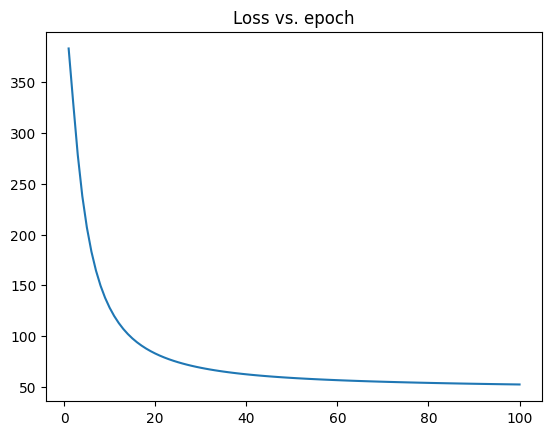

In [17]:
num_epochs = 50
logistic_model_pca = LogisticRegModel(X_reduced_train.shape[1], 10, device=device)

log_loss = logistic_model_pca.fit(X_reduced_train, y_train, num_epochs=num_epochs, lr=1e-3)

epoch_plot = list(range(1, num_epochs+1))

plt.plot(epoch_plot, log_loss)
plt.title("Loss vs. epoch")
plt.show()

In [18]:
y_preds = logistic_model_pca.predict(X_reduced_test)
logistic_model_pca.eval(y_test, y_preds, accuracy_score)

0.9103571428571429